In [6]:
!python3 -m pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 5.2 MB/s eta 0:00:0000:0100:01


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
sns.set(style="whitegrid")

In [8]:
df = pd.read_csv("1739523823_ausapparalsales4thqrt2020.zip")
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [9]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [10]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [11]:
df[df.isna().any(axis=1)]

,Date,Time,State,Group,Unit,Sales


In [12]:
df = df.dropna()

In [43]:
df[df["Sales"] < 0]
df[df["Unit"] < 0]

,Time,State,Group,Unit,Sales,Sales_Normalized,Units_Normalized,Hour
Date,,,,,,,,


In [15]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [16]:
df.columns = df.columns.str.strip()
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [18]:
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
df["Unit"] = df["Unit"].fillna(df["Unit"].median())

In [19]:
df[df["Sales"] < 0]
df[df["Unit"] < 0]

,Date,Time,State,Group,Unit,Sales


In [20]:
df["Sales_Normalized"] = (df["Sales"] - df["Sales"].min()) / (df["Sales"].max() - df["Sales"].min())

df["Units_Normalized"] = (df["Unit"] - df["Unit"].min()) / (df["Unit"].max() - df["Unit"].min())

In [21]:
state_sales = df.groupby("State")["Sales"].sum()
state_sales

State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64

In [22]:
df["Sales"].mean()
df["Sales"].median()
df["Sales"].mode()
df["Sales"].std()

np.float64(32253.506943966073)

In [23]:
df["Unit"].mean()
df["Unit"].median()
df["Unit"].mode()
df["Unit"].std()

np.float64(12.90140277758643)

In [24]:
state_sales = df.groupby("State")["Sales"].sum()

highest_state = state_sales.idxmax()
lowest_state = state_sales.idxmin()

highest_state, lowest_state

(' VIC', ' WA')

In [25]:
group_sales = df.groupby("Group")["Sales"].sum()
group_sales

Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64

In [26]:
group_sales.idxmax()
group_sales.idxmin()

' Seniors'

In [27]:
df["Date"] = pd.to_datetime(df["Date"])

In [28]:
df.set_index("Date", inplace=True)

In [33]:
weekly_sales = df["Sales"].resample("W").sum()

In [30]:
monthly_sales = df["Sales"].resample("ME").sum()

In [35]:
quarterly_sales = df["Sales"].resample("QE").sum()

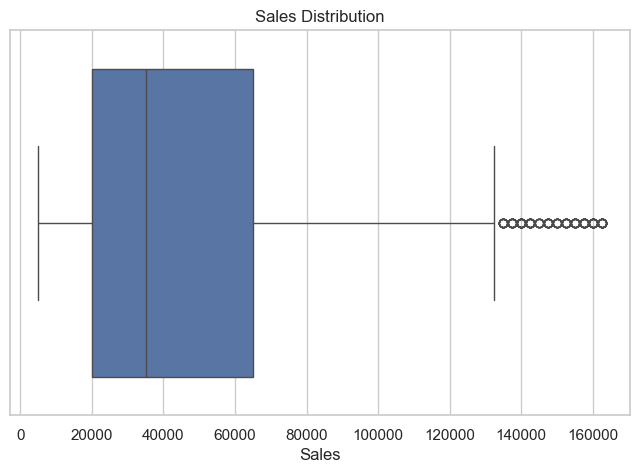

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Sales Distribution")
plt.show()

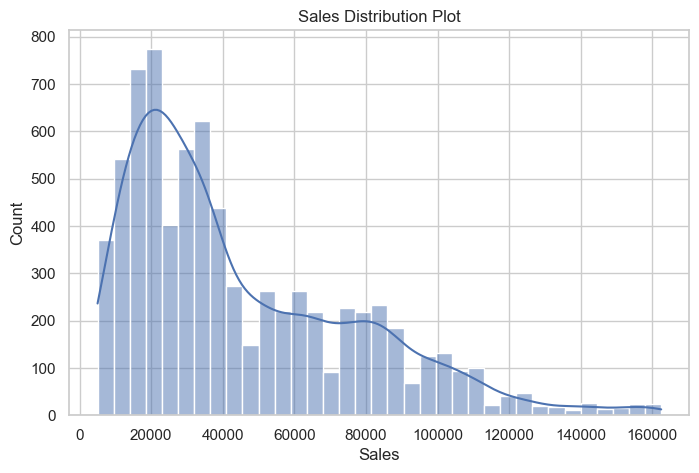

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution Plot")
plt.show()

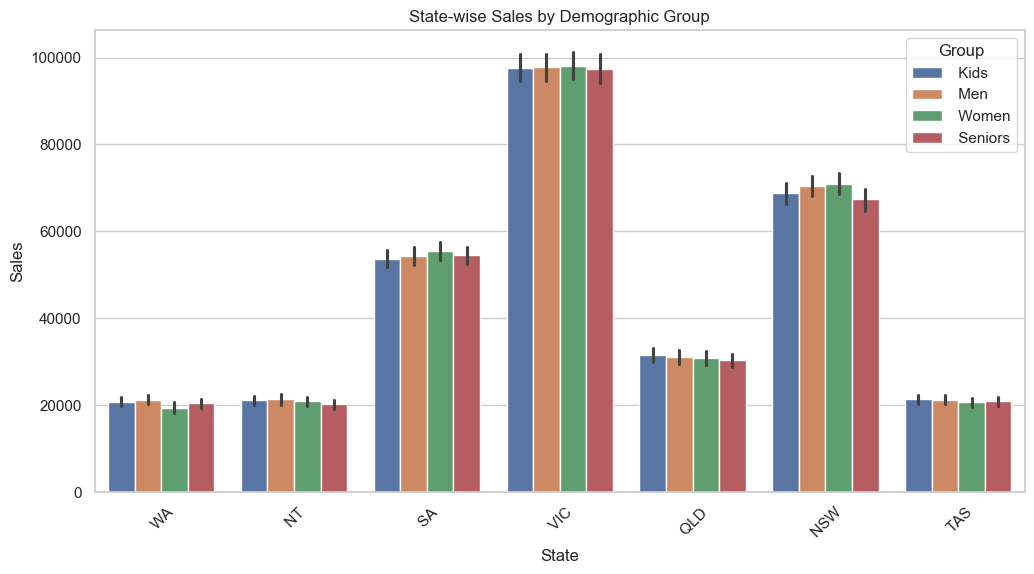

In [38]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x="State", y="Sales", hue="Group")
plt.xticks(rotation=45)
plt.title("State-wise Sales by Demographic Group")
plt.show()

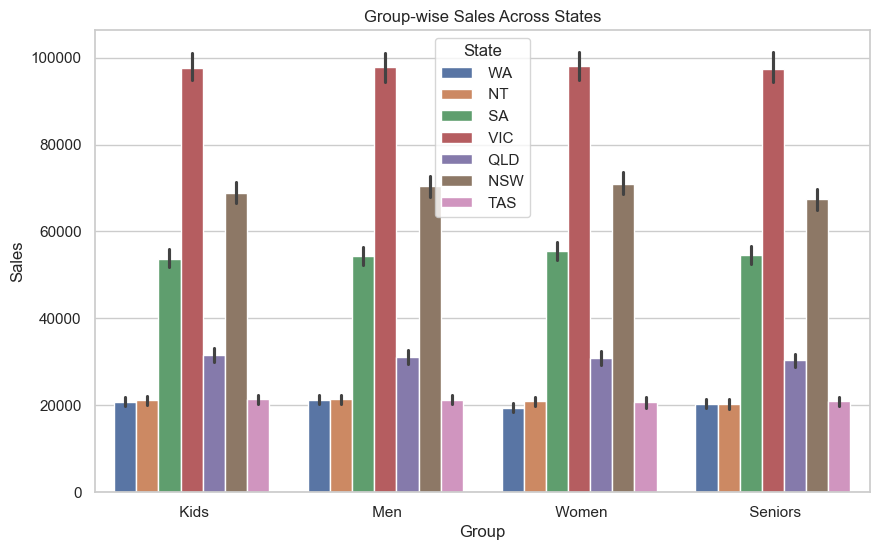

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Group", y="Sales", hue="State")
plt.title("Group-wise Sales Across States")
plt.show()

In [40]:
df["Hour"] = df.index.hour

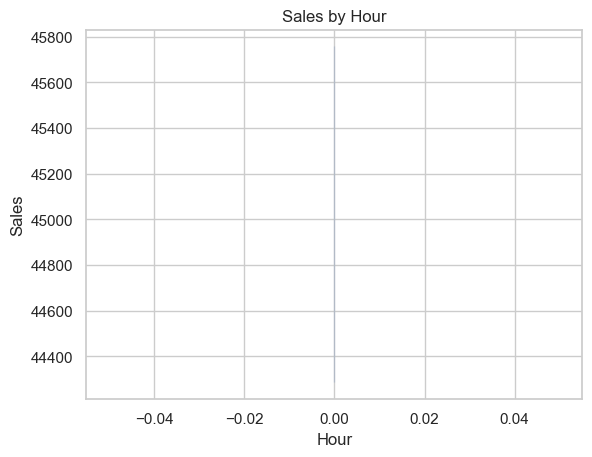

In [41]:
sns.lineplot(data=df, x="Hour", y="Sales")
plt.title("Sales by Hour")
plt.show()

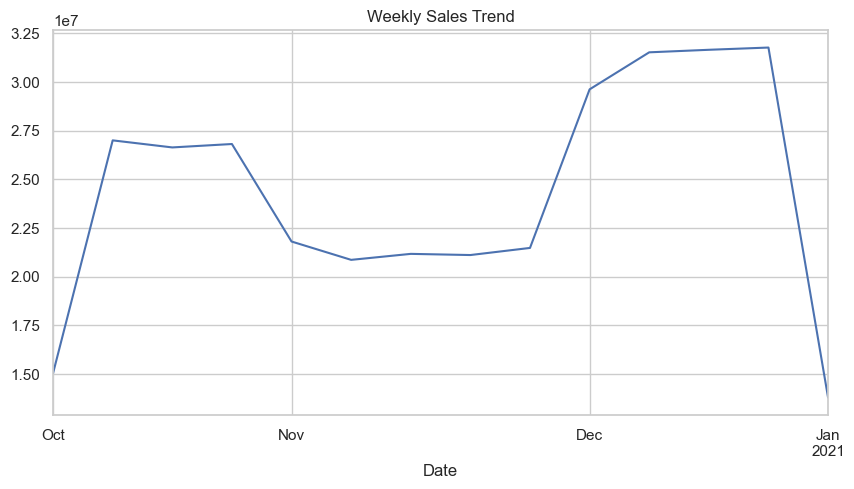

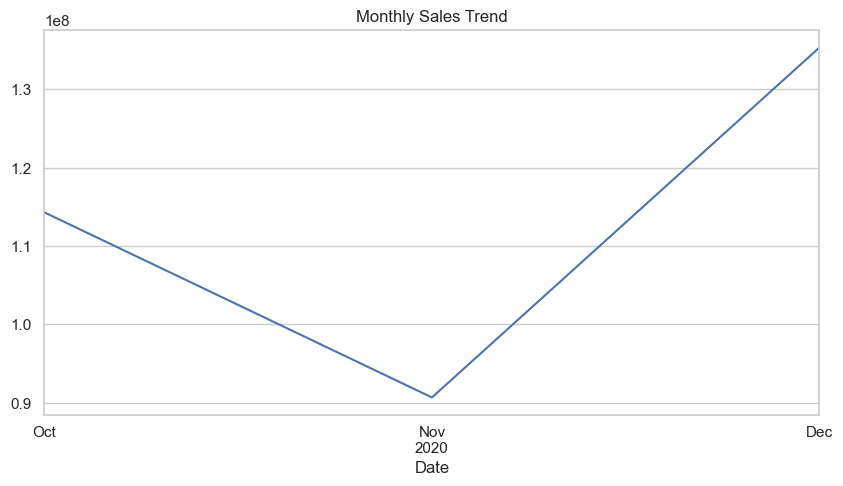

In [42]:
weekly_sales.plot(figsize=(10,5), title="Weekly Sales Trend")
plt.show()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.show()

✅ STEP 7: Business Insights (Very Important)

Now answer the CEO’s questions:

1️⃣ Highest Revenue State

(From idxmax result)

2️⃣ Lowest Revenue State

(From idxmin result)

3️⃣ Sales Program Recommendations

For low-performing states:

Offer seasonal discounts

Introduce loyalty programs

Hyper-personalized promotions

Local influencer marketing

Adjust inventory based on demographic trends

4️⃣ Peak Time Strategy

Increase staff during peak hours

Push flash sales during off-peak hours

# AAL Q4 2020 Sales Analysis Report

## 1. Introduction

## 2. Data Wrangling
- Missing values treatment
- Normalization

## 3. Data Analysis
- Descriptive statistics
- State-wise analysis

## 4. Data Visualization
- Boxplot
- Distribution plots
- Dashboard

## 5. Business Recommendations

## 6. Conclusion

🎯 Final Checklist Before Submission

✔ Data cleaned
✔ Missing values handled
✔ Normalization done
✔ GroupBy used
✔ Descriptive statistics
✔ Weekly/monthly/quarterly reports
✔ Boxplot
✔ Seaborn distribution plot
✔ Business recommendations
✔ Markdown explanation